In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/netflix_titles.csv")

In [ ]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [ ]:
df.tail()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8803,s8804,TV Show,Zombie Dumb,NaN,NaN,NaN,"July 1, 2019",2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."
8806,s8807,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,"March 2, 2019",2015,TV-14,111 min,"Dramas, International Movies, Music & Musicals",A scrappy but poor boy worms his way into a ty...


In [ ]:
df.shape

(8807, 12)

In [ ]:
df.shape[0]

8807

In [ ]:
df.shape[1]

12

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [ ]:
df.describe(include="all")

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
count,8807,8807,8807,6173,7982,7976,8797,8807.000000,8803,8804,8807,8807
unique,8807,2,8807,4528,7692,748,1767,NaN,17,220,514,8775
top,s8807,Movie,Zubaan,Rajiv Chilaka,David Attenborough,United States,"January 1, 2020",NaN,TV-MA,1 Season,"Dramas, International Movies","Paranormal activity at a lush, abandoned prope..."
freq,1,6131,1,19,19,2818,109,NaN,3207,1793,362,4
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2014.180198,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.819312,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1925.000000,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2013.000000,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2017.000000,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019.000000,NaN,NaN,NaN,NaN


In [ ]:
df.columns.tolist()

['show_id',
 'type',
 'title',
 'director',
 'cast',
 'country',
 'date_added',
 'release_year',
 'rating',
 'duration',
 'listed_in',
 'description']

In [ ]:
df["date_added"] = pd.to_datetime(df["date_added"],errors="coerce")

In [ ]:
df["year_added"] = df["date_added"].dt.year

In [ ]:
missing_values = df.isnull().sum()
missing_values

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,0
date_added,98
release_year,0
rating,0
duration,3


In [ ]:
df["rating"] = df["rating"].fillna("Unknown")

In [ ]:
df["country"] = df["country"].fillna("Unknown")


In [ ]:
df["duration_num"] = pd.to_numeric(df["duration"].str.extract(r"(\d+)")[0],errors="coerce")

In [ ]:
df[["type","title","duration","duration_num"]].head(20)

,type,title,duration,duration_num
0,Movie,Dick Johnson Is Dead,90 min,90.0
1,TV Show,Blood & Water,2 Seasons,2.0
2,TV Show,Ganglands,1 Season,1.0
3,TV Show,Jailbirds New Orleans,1 Season,1.0
4,TV Show,Kota Factory,2 Seasons,2.0
5,TV Show,Midnight Mass,1 Season,1.0
6,Movie,My Little Pony: A New Generation,91 min,91.0
7,Movie,Sankofa,125 min,125.0
8,TV Show,The Great British Baking Show,9 Seasons,9.0
9,Movie,The Starling,104 min,104.0


In [ ]:
missing_percentage = (df.isnull().sum() / len(df) * 100)


In [ ]:
missing_table = pd.DataFrame({"Missing Values": df.isnull().sum(),"Percentage": missing_percentage})
missing_table.sort_values(by="Missing Values", ascending=False)

,Missing Values,Percentage
director,2634,29.908028
cast,825,9.367549
year_added,98,1.112751
date_added,98,1.112751
duration,3,0.034064
duration_num,3,0.034064
country,0,0.000000
title,0,0.000000
show_id,0,0.000000
type,0,0.000000


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
content_year = pd.crosstab(df["year_added"], df["type"]).sort_index()
content_year

type,Movie,TV Show
year_added,,
2008.0,1,1
2009.0,2,0
2010.0,1,0
2011.0,13,0
2012.0,3,0
2013.0,6,4
2014.0,19,4
2015.0,56,17
2016.0,253,165


**Netflix Content Growth Over Time**

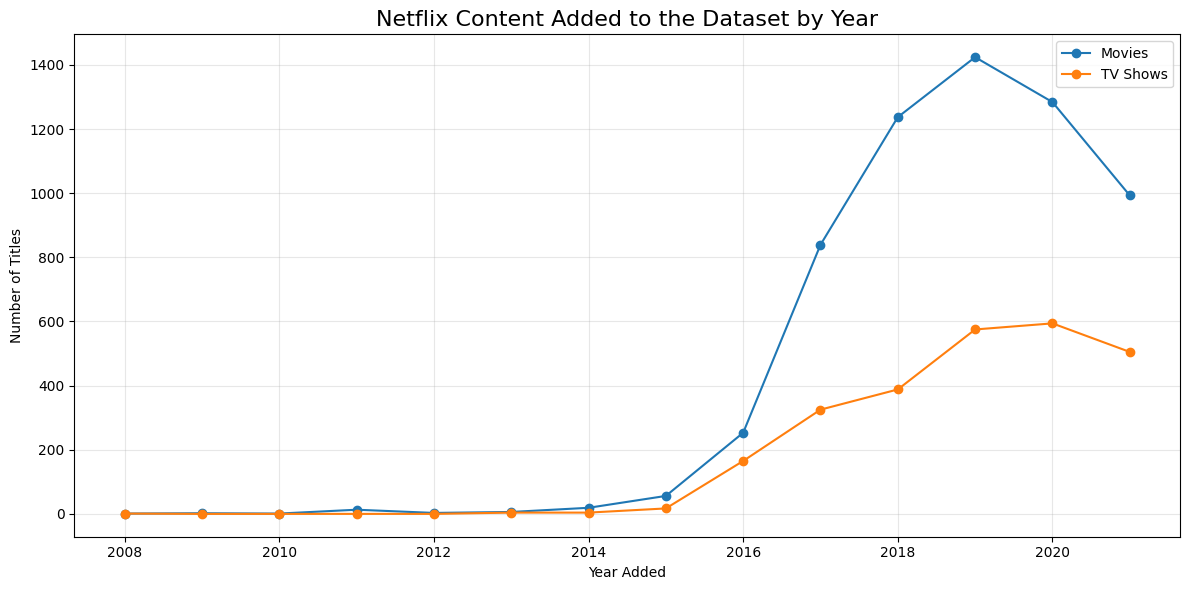

In [32]:
plt.figure(figsize=(12, 6))
plt.plot(content_year.index, content_year["Movie"], marker="o", label="Movies")
plt.plot(content_year.index,content_year["TV Show"],marker="o", label="TV Shows")
plt.title(
    "Netflix Content Added to the Dataset by Year",
    fontsize=16
)

plt.xlabel("Year Added")
plt.ylabel("Number of Titles")
plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

 ***Stacked Area Chart***

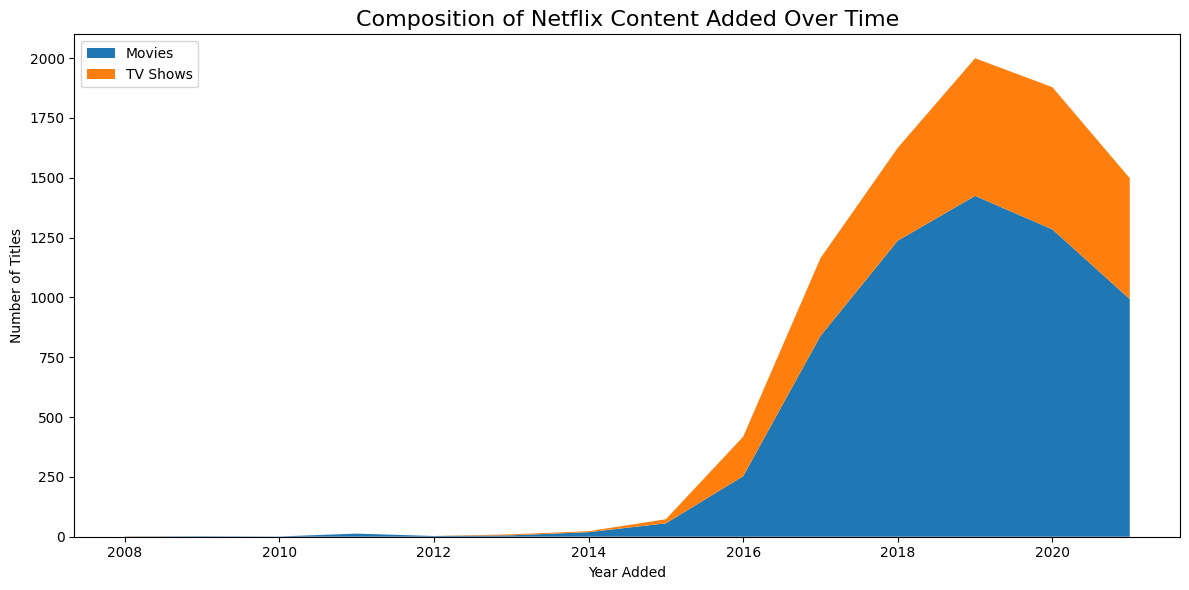

In [34]:
plt.figure(figsize=(12, 6))

plt.stackplot(
    content_year.index,
    content_year["Movie"],
    content_year["TV Show"],
    labels=["Movies", "TV Shows"]
)

plt.title(
    "Composition of Netflix Content Added Over Time",
    fontsize=16
)

plt.xlabel("Year Added")
plt.ylabel("Number of Titles")

plt.legend(
    loc="upper left"
)

plt.tight_layout()

plt.show()

***Top 10 Countries***

In [39]:
countries = (df["country"].dropna().str.split(", ").explode())
countries.head(20)

,country
0,United States
1,South Africa
2,Unknown
3,Unknown
4,India
5,Unknown
6,Unknown
7,United States
7,Ghana
7,Burkina Faso


In [40]:
top_countries = (countries.value_counts().head(10).sort_values())

top_countries

,count
country,
Germany,226
South Korea,231
Spain,232
Japan,318
France,393
Canada,445
United Kingdom,804
Unknown,831
India,1046


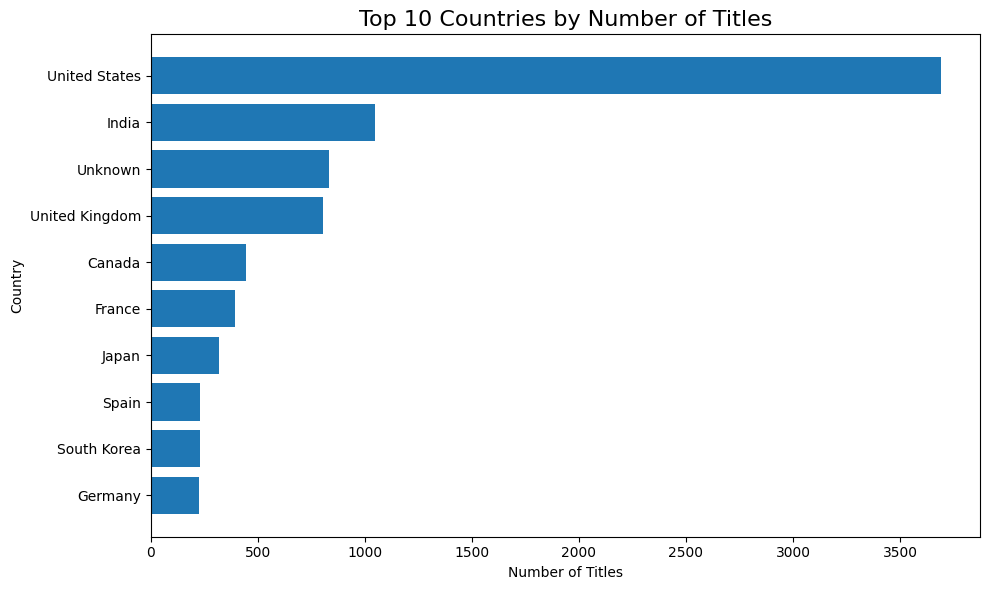

In [41]:
plt.figure(figsize=(10, 6))

plt.barh(
    top_countries.index,
    top_countries.values
)

plt.title(
    "Top 10 Countries by Number of Titles",
    fontsize=16
)

plt.xlabel("Number of Titles")
plt.ylabel("Country")

plt.tight_layout()

plt.show()

***Content Rating Distribution***

In [42]:
rating_counts = ( df["rating"].value_counts().head(10).sort_values())

rating_counts

,count
rating,
NR,80
TV-G,220
PG,287
TV-Y,307
TV-Y7,334
PG-13,490
R,799
TV-PG,863
TV-14,2160


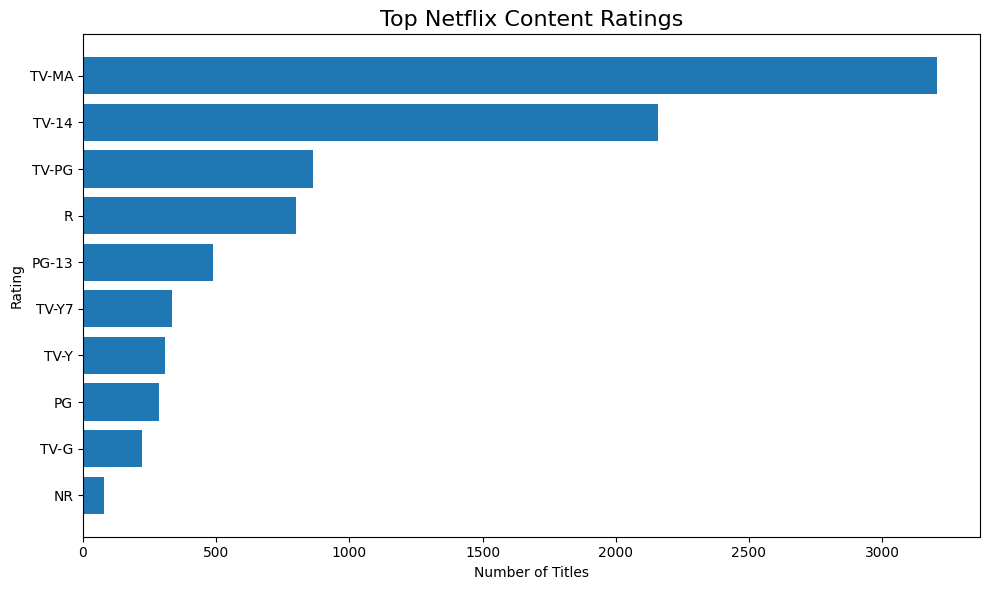

In [43]:
plt.figure(figsize=(10, 6))

plt.barh(
    rating_counts.index,
    rating_counts.values
)

plt.title(
    "Top Netflix Content Ratings",
    fontsize=16
)

plt.xlabel("Number of Titles")
plt.ylabel("Rating")

plt.tight_layout()

plt.show()

***Movie Duration by Rating***

In [44]:
movies = df[df["type"] == "Movie"].copy()

In [45]:
top_movie_ratings = (movies["rating"].value_counts().head(6).index)

top_movie_ratings

Index(['TV-MA', 'TV-14', 'R', 'TV-PG', 'PG-13', 'PG'], dtype='object', name='rating')

In [46]:
movie_rating_data = movies[movies["rating"].isin(top_movie_ratings)]

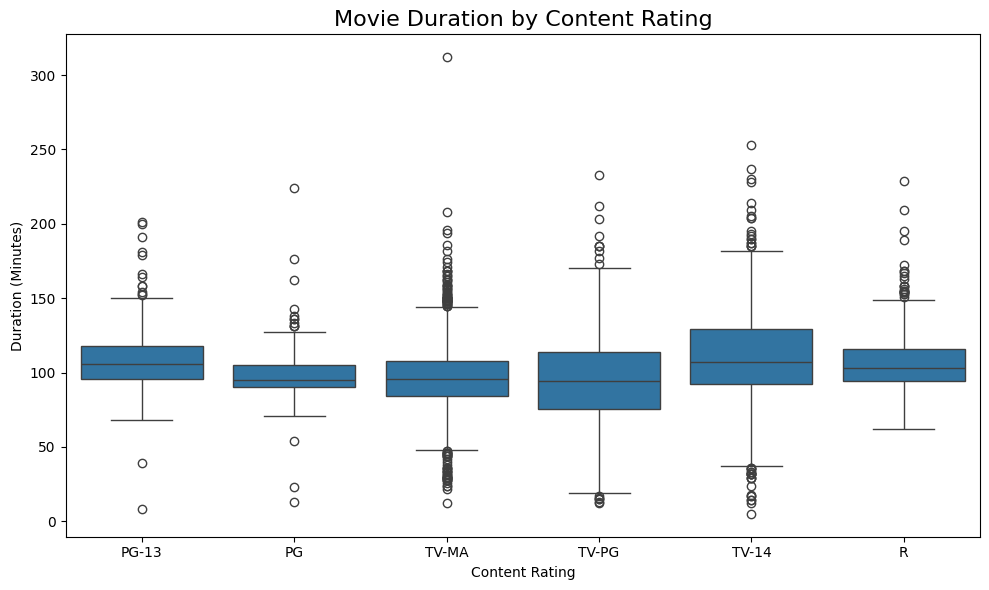

In [47]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=movie_rating_data,
    x="rating",
    y="duration_num"
)

plt.title(
    "Movie Duration by Content Rating",
    fontsize=16
)

plt.xlabel("Content Rating")
plt.ylabel("Duration (Minutes)")

plt.tight_layout()

plt.show()

In [48]:
round(movies["duration_num"].mean(),2)

np.float64(99.58)

***Year × Content Type Heatmap***

In [49]:
heatmap_data = content_year.T

heatmap_data

year_added,2008.0,2009.0,2010.0,2011.0,2012.0,2013.0,2014.0,2015.0,2016.0,2017.0,2018.0,2019.0,2020.0,2021.0
type,,,,,,,,,,,,,,
Movie,1,2,1,13,3,6,19,56,253,839,1237,1424,1284,993
TV Show,1,0,0,0,0,4,4,17,165,325,388,575,594,505


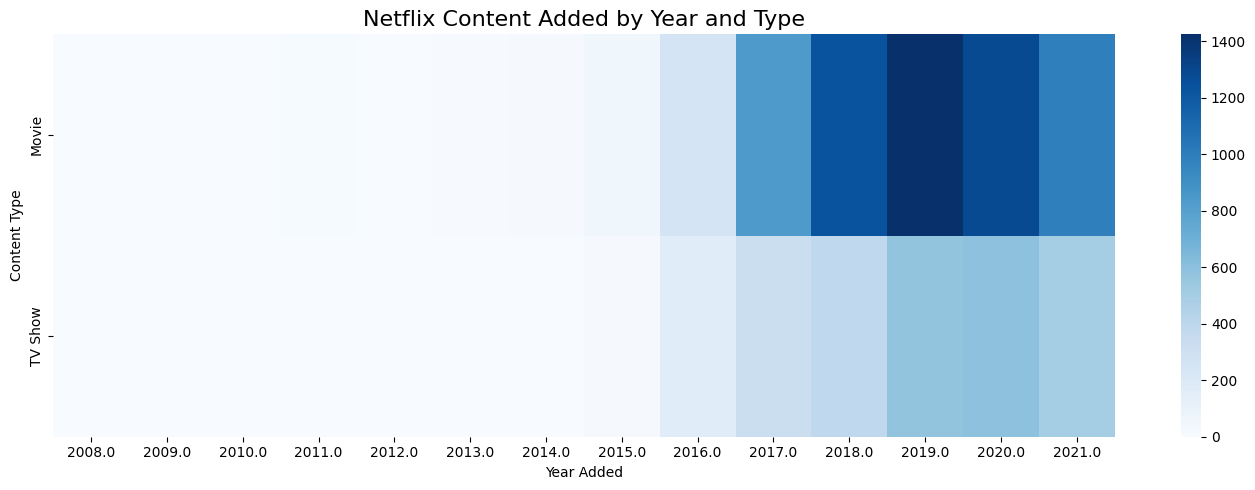

In [50]:
plt.figure(figsize=(14, 5))

sns.heatmap(
    heatmap_data,
    annot=False,
    cmap="Blues"
)

plt.title(
    "Netflix Content Added by Year and Type",
    fontsize=16
)

plt.xlabel("Year Added")
plt.ylabel("Content Type")

plt.tight_layout()

plt.show()

In [53]:
len(df)

8807

In [54]:
(df["type"] == "Movie").sum()

np.int64(6131)

In [55]:
(df["type"] == "TV Show").sum()

np.int64(2676)

In [56]:
df["rating"].value_counts().index[0]

'TV-MA'

In [57]:
countries.value_counts().index[0]

'United States'

In [58]:
numeric_columns = [
    "release_year",
    "year_added",
    "duration_num"
]

correlation = df[
    numeric_columns
].corr()

correlation

,release_year,year_added,duration_num
release_year,1.000000,0.110473,-0.249182
year_added,0.110473,1.000000,0.016436
duration_num,-0.249182,0.016436,1.000000


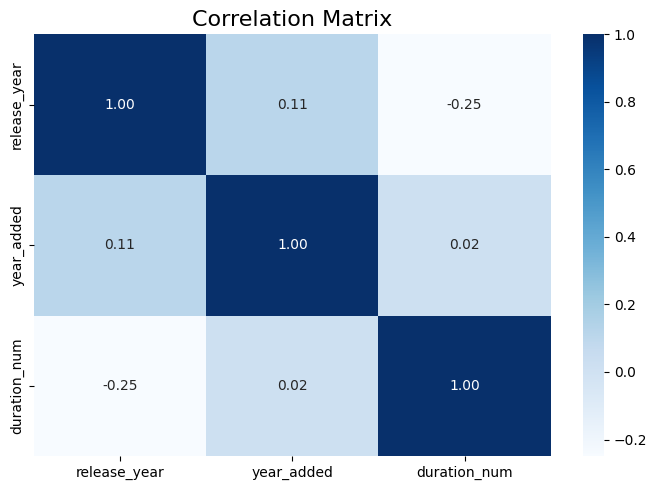

In [59]:
plt.figure(figsize=(7, 5))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="Blues"
)

plt.title(
    "Correlation Matrix",
    fontsize=16
)

plt.tight_layout()

plt.show()